<a href="https://colab.research.google.com/github/kiransree2002/Assessment/blob/main/Intermediate_Assessment_2_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries


In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score)

# Step 1: Load and Explore the Data



In [4]:
#Load the dataset House_Pricing.csv
filepath = "/content/heart_disease (1).csv"
df_heart_disease= pd.read_csv(filepath)
df_heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df_heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df_heart_disease.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df_heart_disease.shape

(1025, 14)

#Step 2: Data Cleaning and Preprocessing

In [8]:
df_heart_disease.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
df_heart_disease.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [10]:
df_heart_disease.duplicated().sum()

np.int64(723)

In [21]:
df_heart_disease.drop_duplicates(inplace= True)

In [22]:
df_heart_disease.shape

(302, 14)

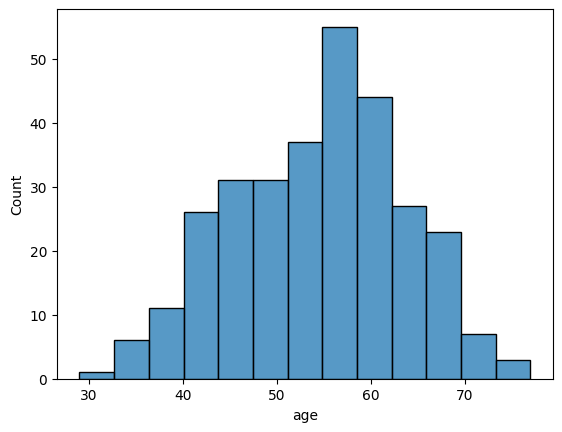

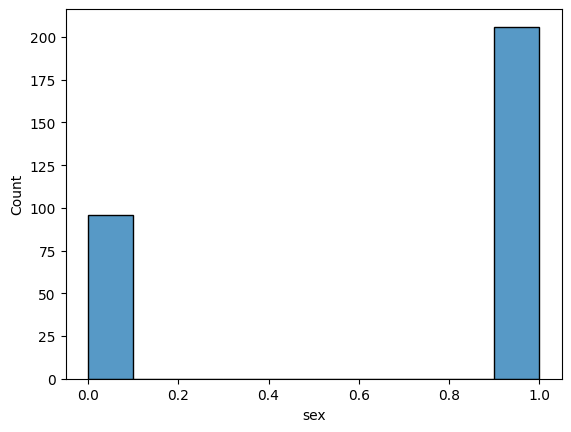

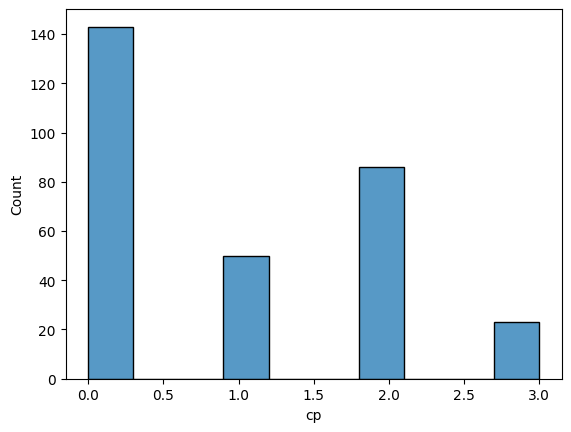

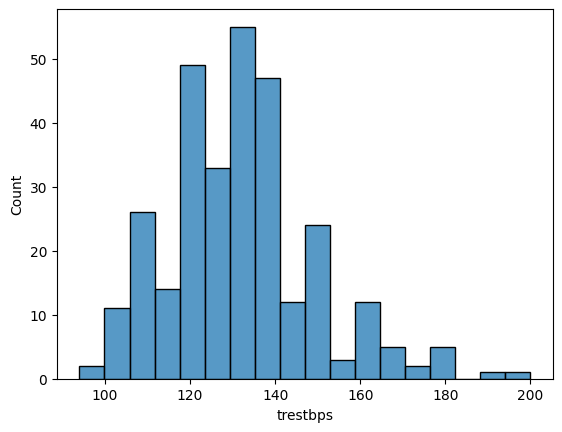

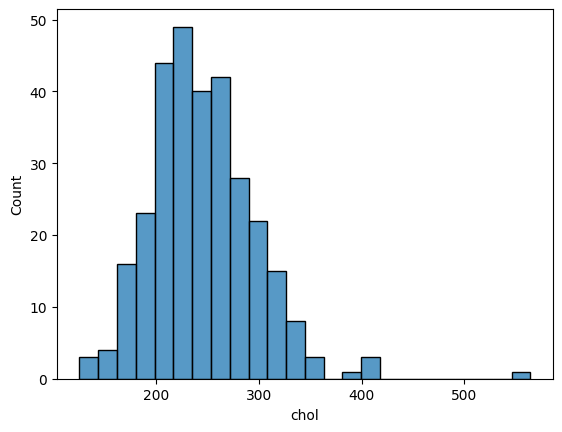

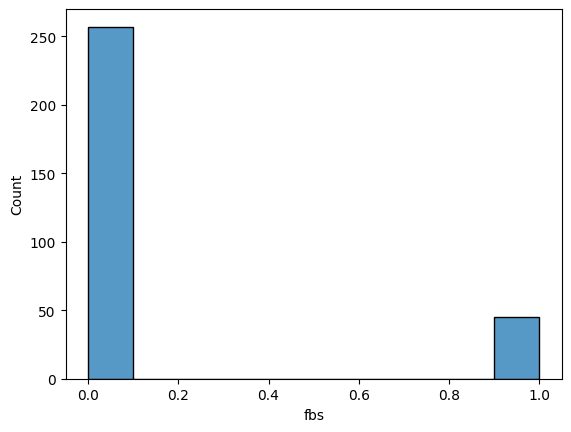

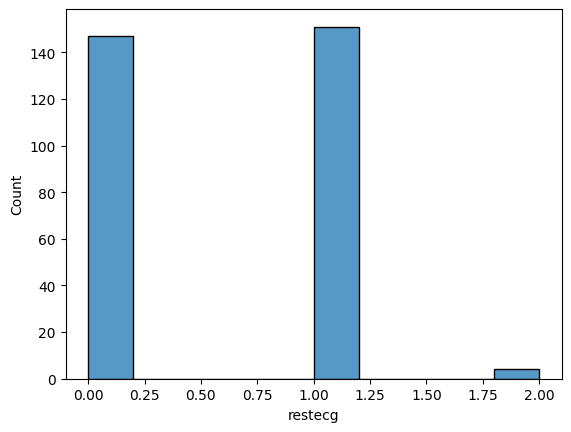

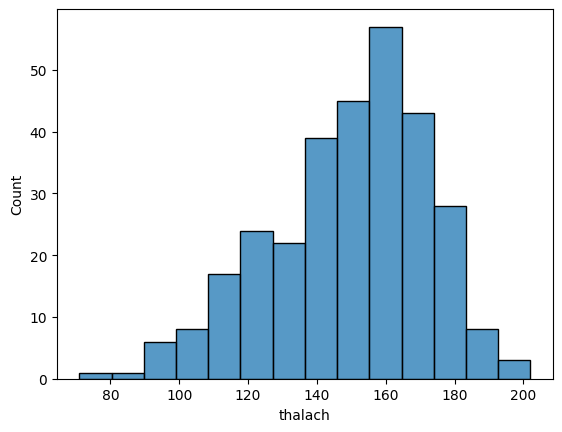

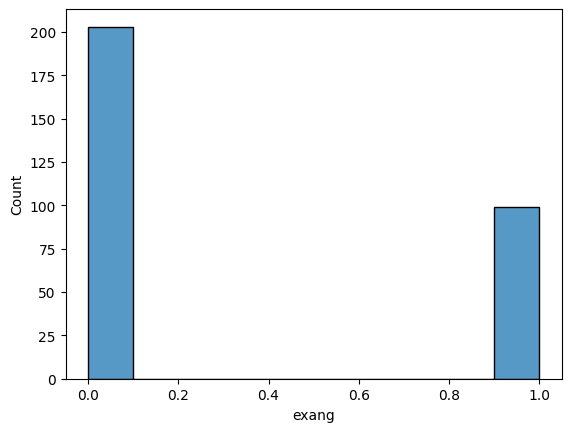

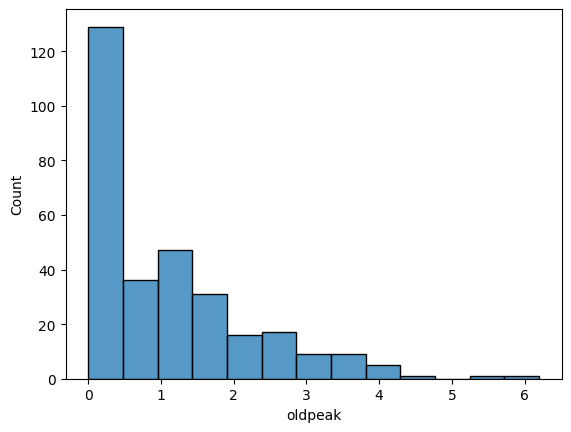

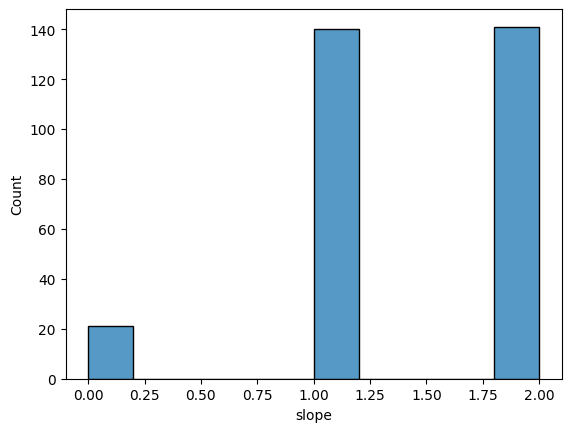

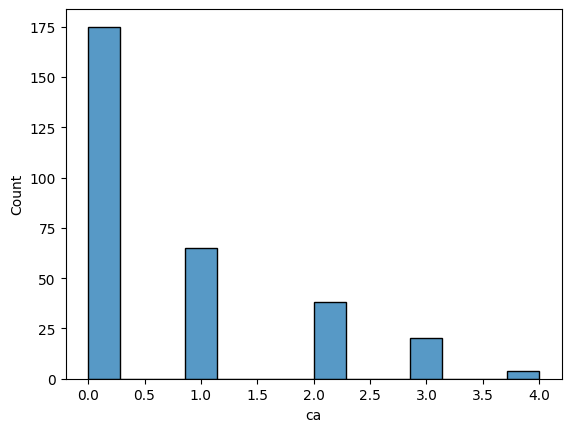

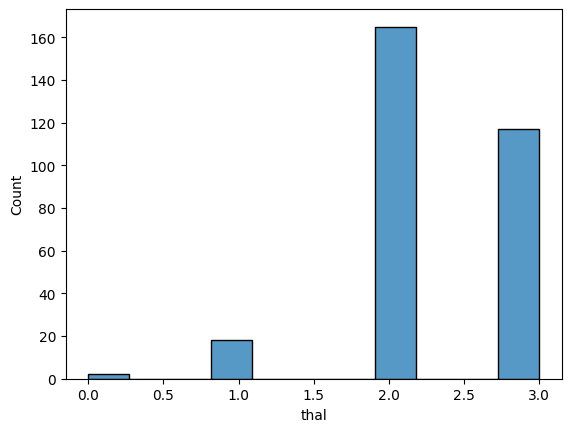

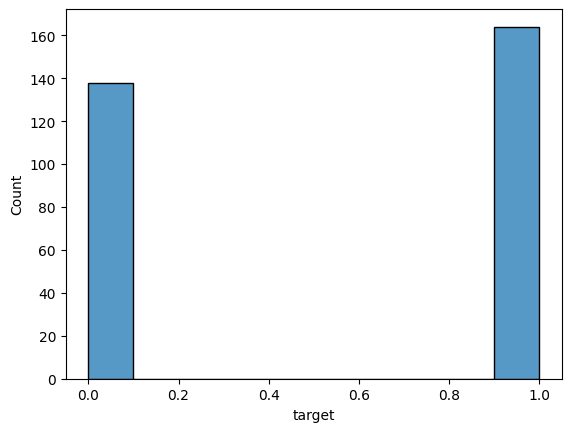

In [25]:
# Histogram
for i in df_heart_disease.select_dtypes(include='number').columns:
  sns.histplot(data = df_heart_disease , x = i)
  plt.show()

In [27]:
#Scatter Plot
df_heart_disease.select_dtypes(include="number")
df_heart_disease.select_dtypes(include="number").columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

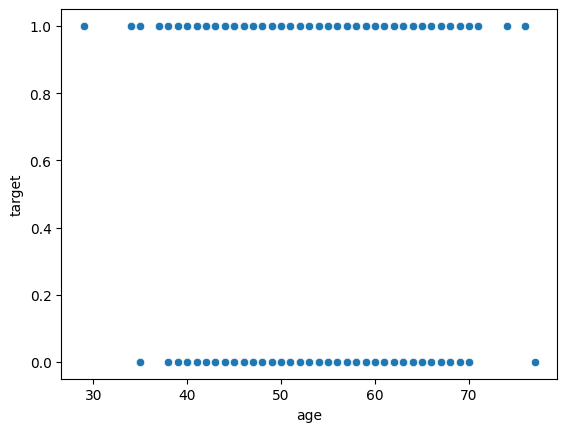

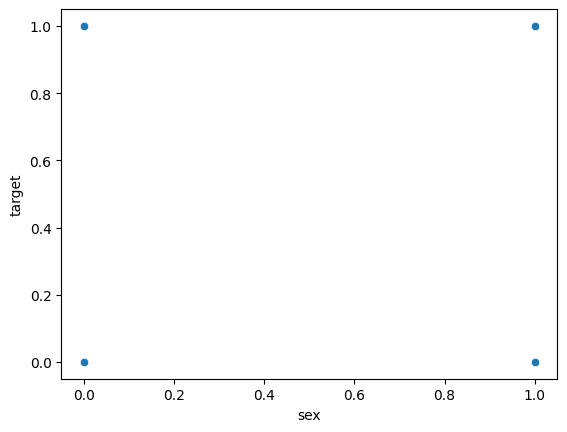

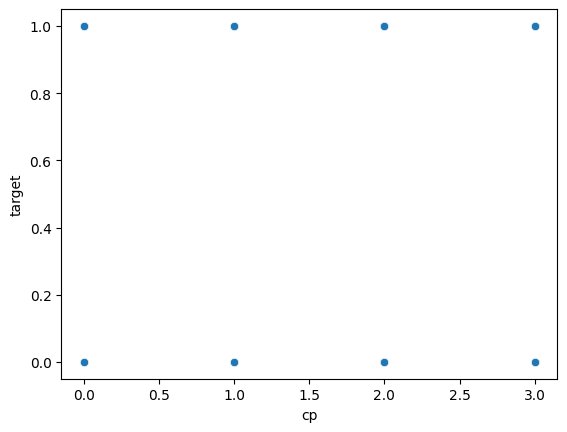

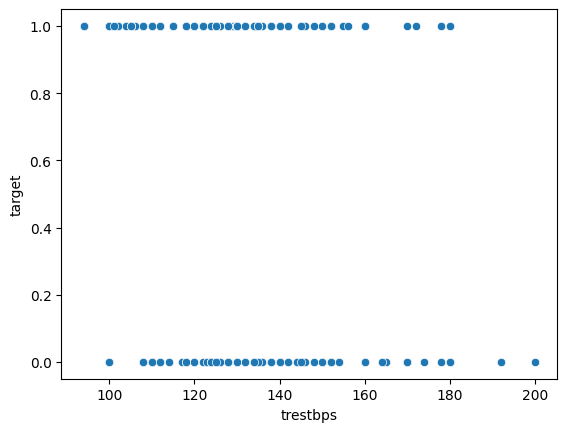

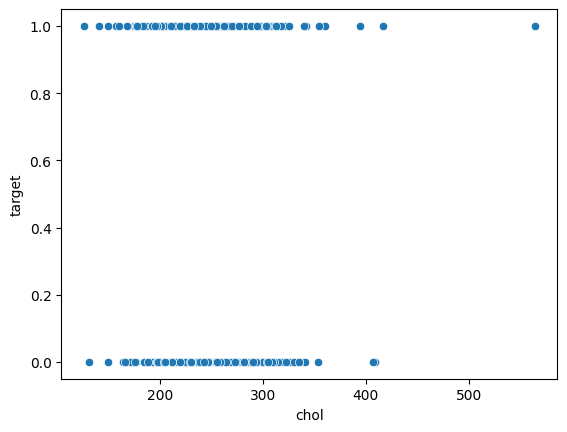

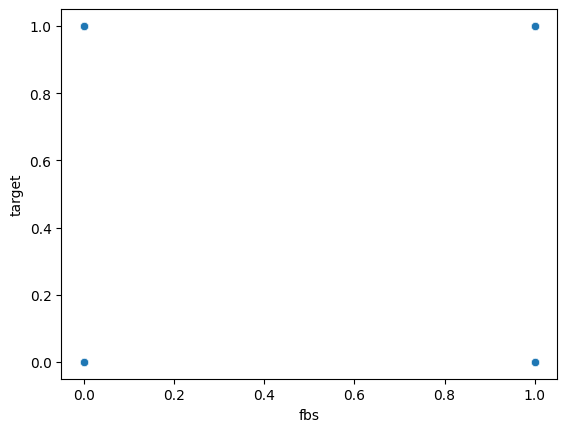

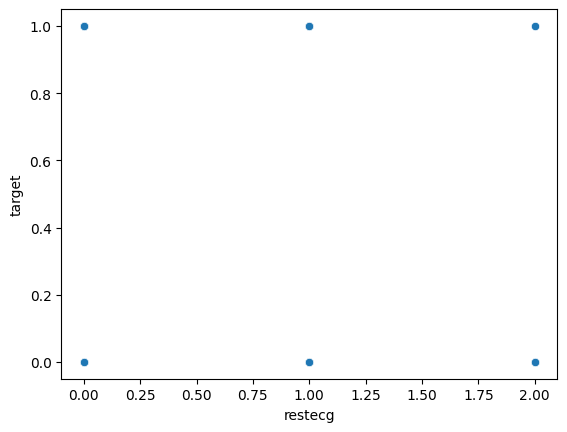

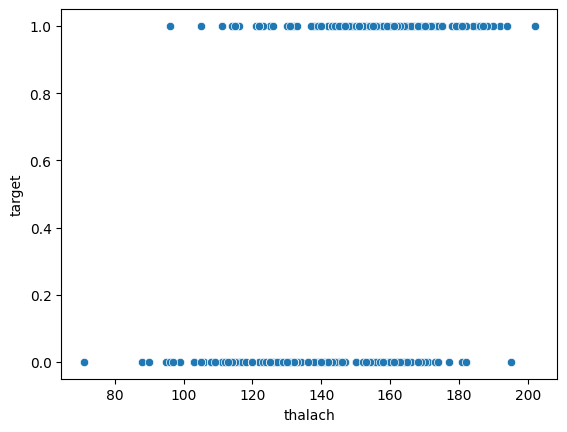

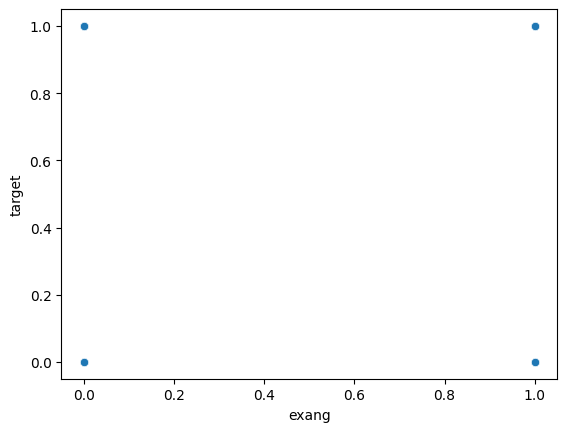

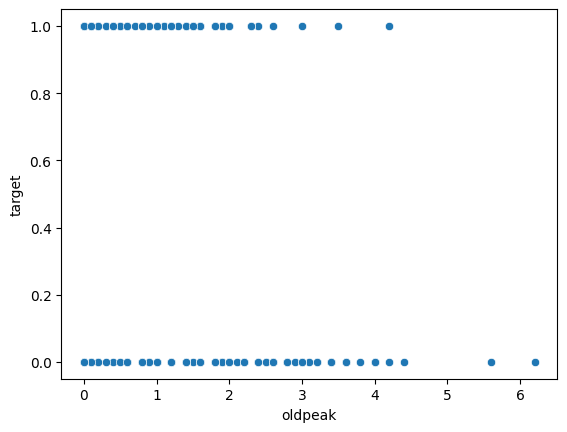

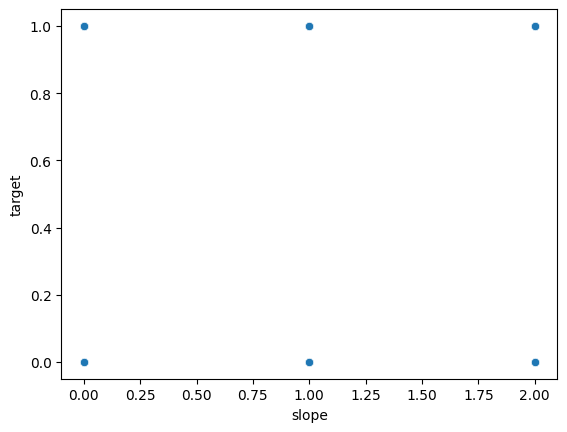

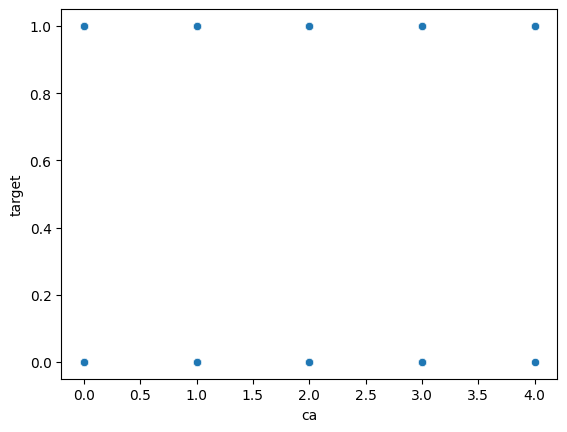

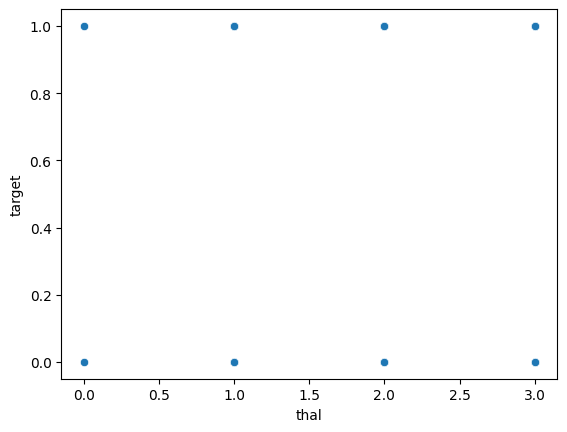

In [29]:
for i in ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']:
       sns.scatterplot(data = df_heart_disease , x = i , y ="target")
       plt.show()

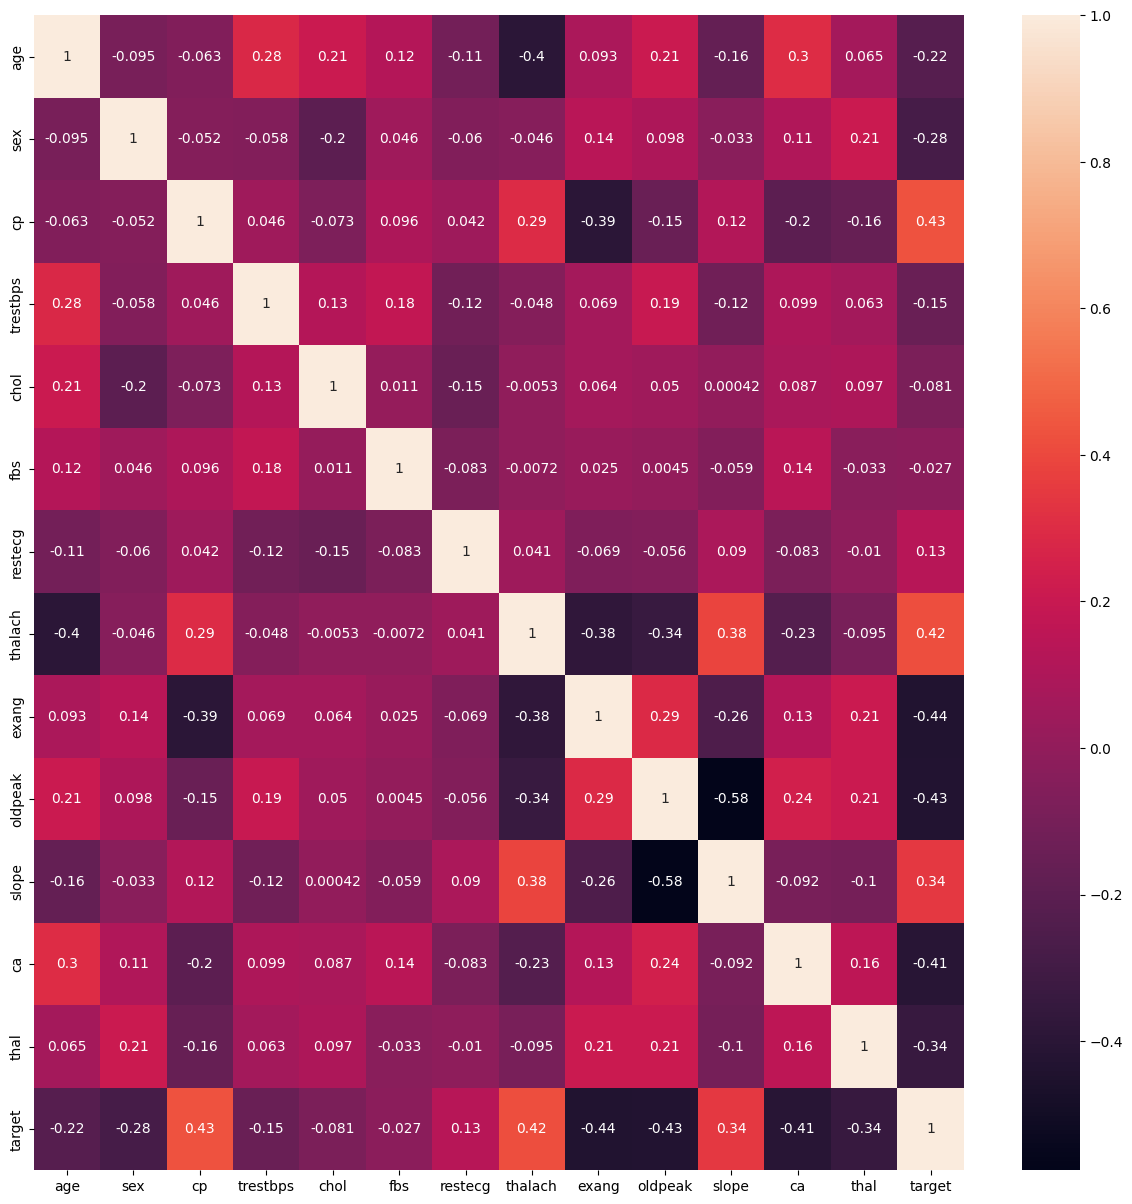

In [30]:
#Correlation
s = df_heart_disease.select_dtypes(include="number").corr()
plt.figure(figsize=(15,15))
sns.heatmap(s, annot=True)
plt.show()

In [40]:
# Identify all categorical columns
cat_cols = df_heart_disease.select_dtypes(include=['object']).columns
print(cat_cols)

Index([], dtype='object')


In [41]:
#Identify all numerical columns
num_cols = df_heart_disease.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('target')
print(num_cols)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


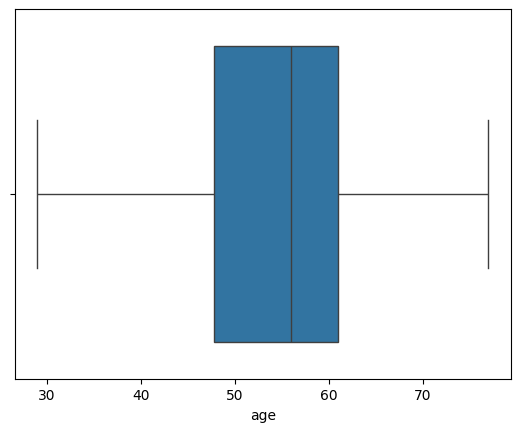

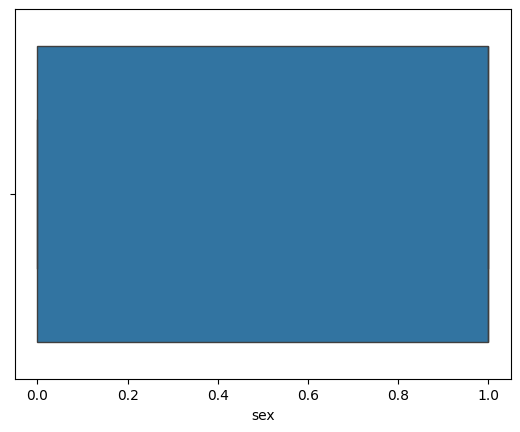

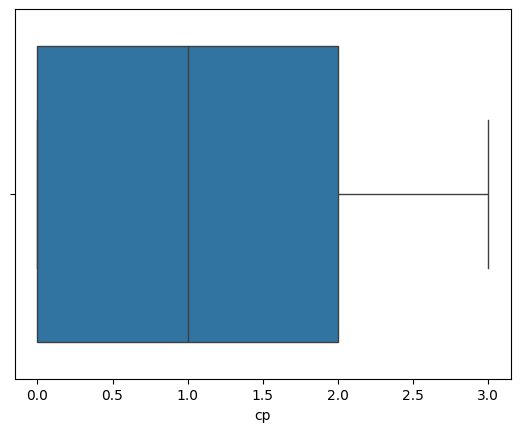

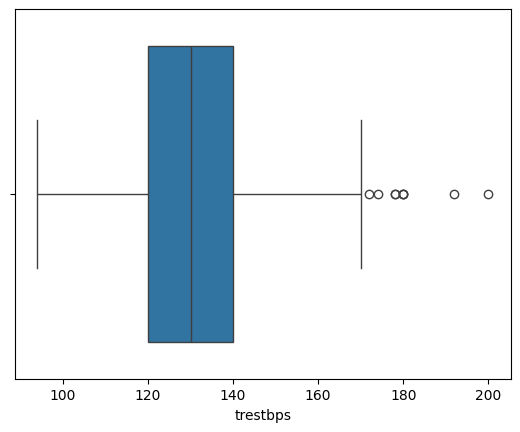

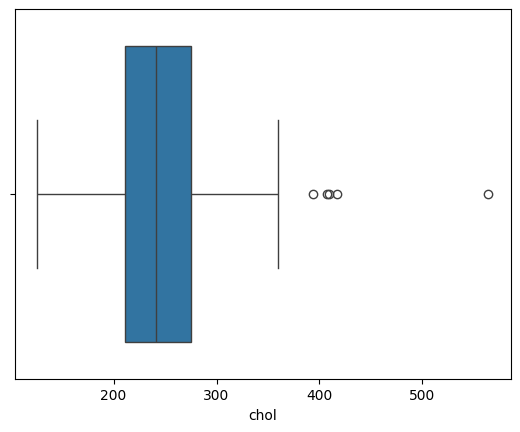

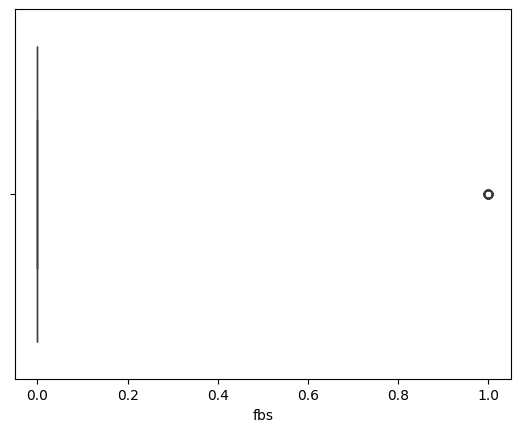

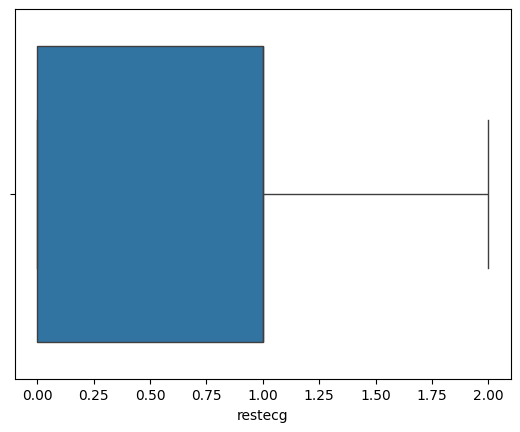

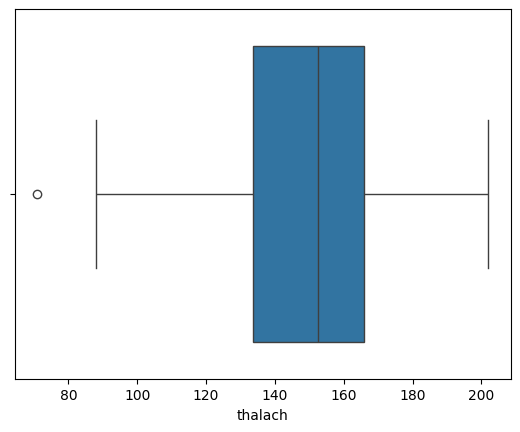

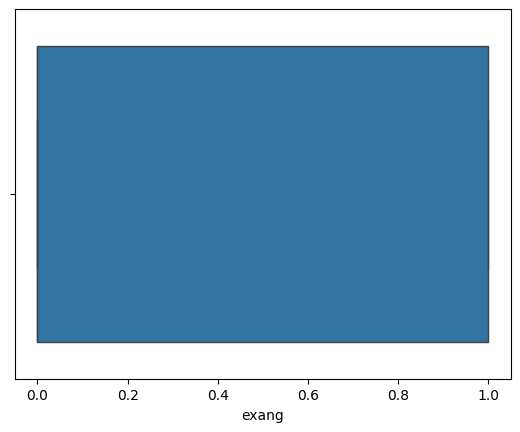

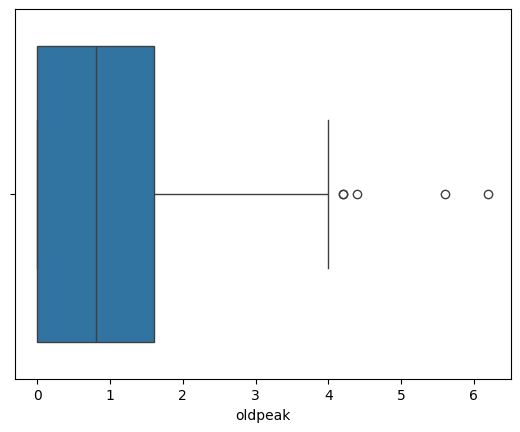

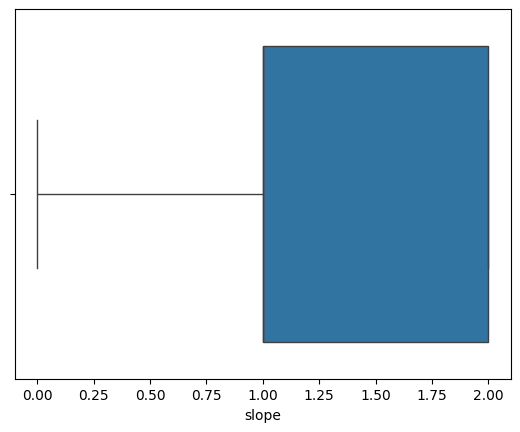

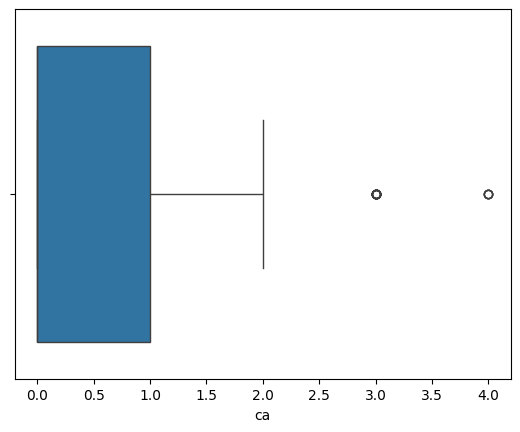

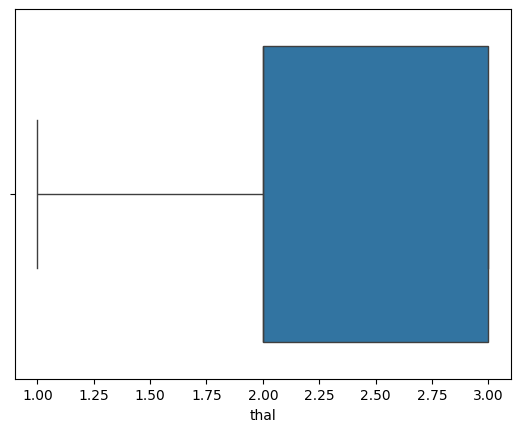

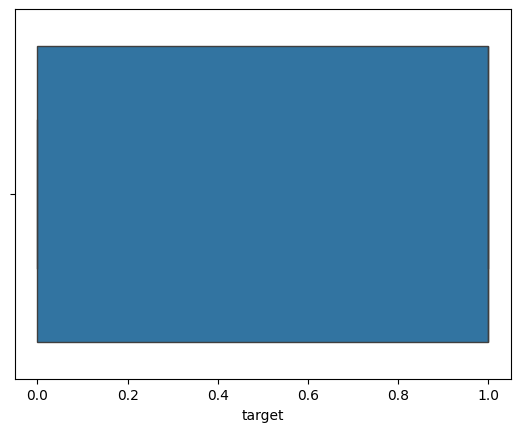

In [42]:
#Boxplot
for i in df_heart_disease.select_dtypes(include='number').columns:
  sns.boxplot(data = df_heart_disease , x = i)
  plt.show()

In [43]:
#outlier detection
for col in num_cols:
  Q1=df_heart_disease[col].quantile(0.25)
  Q3=df_heart_disease[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier = df_heart_disease[(df_heart_disease[col]<lower_bound) | (df_heart_disease[col]<upper_bound)]
  print(f"{col}:{len(outlier)}outliers")


age:300outliers
sex:300outliers
cp:300outliers
trestbps:287outliers
chol:295outliers
fbs:0outliers
restecg:300outliers
thalach:300outliers
exang:300outliers
oldpeak:292outliers
slope:300outliers
ca:276outliers
thal:300outliers


In [44]:
#removal of outliers
df_heart_disease = df_heart_disease[(df_heart_disease[col]>= lower_bound) & (df_heart_disease[col] <= upper_bound)]
df_heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Encoding Techniques

In [62]:
df_heart_disease['cp'].unique()

array([-0.93479548,  0.03558045,  1.00595638,  1.9763323 ])

In [63]:
df_heart_disease['restecg'].unique()

array([ 0.90104715, -1.00257359,  2.8046679 ])

In [64]:
df_heart_disease['thal'].unique()

array([ 1.14718628, -0.56503205, -2.27725037])

In [65]:
# OneHot Encoding
ohe_cols = ['cp','restecg','thal']
df_heart_disease_ohe = pd.get_dummies(df_heart_disease , columns=ohe_cols , dtype = int)
df_heart_disease_ohe.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_-0.9347954752153868,cp_0.0355804506137344,cp_1.0059563764428556,cp_1.9763323022719768,restecg_-1.0025735928035178,restecg_0.9010471530259466,restecg_2.8046678988554112,thal_-2.2772503697563127,thal_-0.5650320466312656,thal_1.1471862764937812
0,-0.268533,0.680746,-0.376726,-0.671355,-0.414578,0.802428,-0.696526,-0.040167,0.979610,1.268163,...,1,0,0,0,0,1,0,0,0,1
1,-0.158177,0.680746,0.476024,-0.845265,2.412091,0.233537,1.435697,1.767344,-2.267716,-0.718515,...,1,0,0,0,1,0,0,0,0,1
2,1.717876,0.680746,0.760273,-1.405640,-0.414578,-1.079288,1.435697,1.336985,-2.267716,-0.718515,...,1,0,0,0,0,1,0,0,0,1
3,0.724671,0.680746,0.930823,-0.845265,-0.414578,0.496102,-0.696526,-0.900887,0.979610,0.274824,...,1,0,0,0,0,1,0,0,0,1
4,0.835027,-1.468977,0.362324,0.913154,2.412091,-1.910744,-0.696526,0.734481,-0.644053,2.261503,...,1,0,0,0,0,1,0,0,1,0


In [66]:
#binary encoding
df_heart_disease["sex"] = df_heart_disease["sex"].astype(int)
df_heart_disease["fbs"] = df_heart_disease["fbs"].astype(int)

In [67]:
# Scaling by using Standard scaler
cols_to_scale = ['trestbps', 'chol', 'thalach', 'oldpeak']

X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(X_train[cols_to_scale].describe())

           trestbps          chol       thalach       oldpeak
count  2.410000e+02  2.410000e+02  2.410000e+02  2.410000e+02
mean   4.127634e-16 -2.045390e-16  5.159543e-16  1.289886e-17
std    1.002081e+00  1.002081e+00  1.002081e+00  1.002081e+00
min   -2.141253e+00 -2.276049e+00 -3.382861e+00 -8.906349e-01
25%   -6.348995e-01 -6.895756e-01 -7.503143e-01 -8.906349e-01
50%   -5.553267e-02 -9.231515e-02  1.991288e-01 -3.589016e-01
75%    5.238341e-01  5.422740e-01  7.170068e-01  5.273206e-01
max    4.000035e+00  5.898953e+00  2.270641e+00  4.072209e+00


#Step 3: Train-Test Split

##Define X and y

In [69]:
y = df_heart_disease['target']
X = df_heart_disease.drop(columns=['target'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 13)
y shape: (300,)


##Split into 80% Train & 20% Test:

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

###Verify the Split

In [71]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (240, 13)
X_test: (60, 13)
y_train: (240,)
y_test: (60,)


In [83]:
# Regression
X_reg = df_heart_disease.drop(columns=['chol'])
y_reg = df_heart_disease['chol']


X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [84]:
reg_scale_cols = ['trestbps', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_train[reg_scale_cols] = scaler.fit_transform(X_train[reg_scale_cols])
X_test[reg_scale_cols]  = scaler.transform(X_test[reg_scale_cols])

In [85]:
# Classification
X_clf = df_heart_disease_ohe.drop(columns=['target'])
y_clf = df_heart_disease_ohe['target']

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [86]:
clf_scale_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_train[clf_scale_cols] = scaler.fit_transform(X_train[clf_scale_cols])
X_test[clf_scale_cols]  = scaler.transform(X_test[clf_scale_cols])

print("Regression -> X_train:", X_train.shape, "X_test:", X_test.shape)
print("Classification -> X_train:", X_train.shape, "X_test:", X_test.shape)

Regression -> X_train: (240, 20) X_test: (60, 20)
Classification -> X_train: (240, 20) X_test: (60, 20)


#Step 4: Build Machine Learning Models

In [91]:
#Regression models
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

svr = SVR(kernel='rbf', C=10, gamma='scale')
svr.fit(X_train, y_train)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=42)
rf_reg.fit(X_train, y_train)

#Classification models
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

#Step 5: Evaluate Models on Test Data

In [90]:
# ---- Regression evaluation ----
reg_models = {'Linear Regression': lin_reg, 'SVM (SVR)': svr, 'Random Forest': rf_reg}
reg_results = {}

for name, model in reg_models.items():
    preds = model.predict(X_test)
    reg_results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'MSE': mean_squared_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    }

reg_results_df = pd.DataFrame(reg_results).T
print(reg_results_df)

# ---- Classification evaluation ----
clf_models = {'Logistic Regression': log_reg, 'KNN': knn, 'Random Forest': rf_clf}
clf_results = {}

for name, model in clf_models.items():
    preds = model.predict(X_test)
    clf_results[name] = {'Accuracy': accuracy_score(y_test, preds),'Precision': precision_score(y_test, preds),'Recall': recall_score(y_test, preds),'F1': f1_score(y_test, preds)}

clf_results_df = pd.DataFrame(clf_results).T
print(clf_results_df)

                        MAE       MSE        R2
Linear Regression  0.279010  0.144229  0.417258
SVM (SVR)          0.298878  0.184491  0.254581
Random Forest      0.273111  0.148288  0.400856
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.816667   0.823529  0.848485  0.835821
KNN                  0.800000   0.862069  0.757576  0.806452
Random Forest        0.766667   0.787879  0.787879  0.787879


#Step 6: Summarize the classification and regression result in a table form and declare the best performing model in each category based on the performance metric choosen..

In [93]:
print("Regression Results")
display(reg_results_df.round(4))
best_reg = reg_results_df['R2'].idxmax()
print(f"\nBest regression model (by R²): {best_reg} (R² = {reg_results_df.loc[best_reg, 'R2']:.4f})")

print("Classification Results")
display(clf_results_df.round(4))
best_clf = clf_results_df['Recall'].idxmax()
print(f"\nBest classification model (by Recall): {best_clf} (Recall = {clf_results_df.loc[best_clf, 'Recall']:.4f})")

Regression Results


,MAE,MSE,R2
Linear Regression,0.2790,0.1442,0.4173
SVM (SVR),0.2989,0.1845,0.2546
Random Forest,0.2731,0.1483,0.4009



Best regression model (by R²): Linear Regression (R² = 0.4173)
Classification Results


,Accuracy,Precision,Recall,F1
Logistic Regression,0.8167,0.8235,0.8485,0.8358
KNN,0.8000,0.8621,0.7576,0.8065
Random Forest,0.7667,0.7879,0.7879,0.7879



Best classification model (by Recall): Logistic Regression (Recall = 0.8485)


#Best Model: Logistic Regression

Reason:

* Highest Accuracy: 81.67%
* Highest Precision: 86.21%
* Highest Recall: 84.85%
* Highest F1 Score: 83.58%